In [1]:
import pandas as pd
import os

# ファイルパス
base_dir = r'C:\Users\xyz19\OneDrive\デスクトップ\予測モデルデータセット'
file_path = os.path.join(base_dir, 'regression_df_20260112_233447.xlsx')

# データを読み込む
print("データを読み込んでいます...")
regressionDF = pd.read_excel(file_path)

print("✓ データの読み込みが完了しました。")

データを読み込んでいます...
✓ データの読み込みが完了しました。


In [2]:
# データの基本情報
print(f"データ形状: {regressionDF.shape}")
print(f"行数: {len(regressionDF)}, 列数: {len(regressionDF.columns)}")

データ形状: (16388, 8)
行数: 16388, 列数: 8


In [4]:
# 列名を確認
regressionDF.columns.tolist()

['Area', 'Item', 'Year', 'SPEI', 'GSL', 'Hurs', 'TXX', 'Yield']

In [5]:
# データ型と基本統計
print("データ型:")
print(regressionDF.dtypes)
print("\n欠損値:")
print(regressionDF.isnull().sum())
print("\n穀物の種類:")
print(regressionDF['Item'].unique())
print("\n国の数:")
print(regressionDF['Area'].nunique())

データ型:
Area      object
Item      object
Year       int64
SPEI     float64
GSL      float64
Hurs     float64
TXX      float64
Yield    float64
dtype: object

欠損値:
Area     0
Item     0
Year     0
SPEI     0
GSL      0
Hurs     0
TXX      0
Yield    0
dtype: int64

穀物の種類:
['Maize (corn)' 'Rice' 'Wheat']

国の数:
156


In [6]:
# 特徴量の準備
from sklearn.model_selection import train_test_split
import numpy as np

# 気候データの列
climate_features = ['SPEI', 'GSL', 'Hurs', 'TXX']

# Area（国）をダミー変数化
area_dummies = pd.get_dummies(regressionDF['Area'], prefix='Area')

# Item（穀物の種類）をダミー変数化
item_dummies = pd.get_dummies(regressionDF['Item'], prefix='Item')

# Yearを特徴量として追加
year_feature = regressionDF[['Year']].copy()

# すべての特徴量を結合
X = pd.concat([
    regressionDF[climate_features],  # 気候データ
    area_dummies,                     # 国ダミー
    item_dummies,                      # 穀物ダミー
    year_feature                      # Year
], axis=1)

# 目的変数
y = regressionDF['Yield'].copy()

print(f"特徴量の形状: {X.shape}")
print(f"特徴量の列数: {len(X.columns)}")
print(f"\n特徴量の最初の5行:")
X.head()

特徴量の形状: (16388, 164)
特徴量の列数: 164

特徴量の最初の5行:


,SPEI,GSL,Hurs,TXX,Area_Afghanistan,Area_Albania,Area_Algeria,Area_Angola,Area_Antigua and Barbuda,Area_Argentina,...,Area_United States of America,Area_Uruguay,Area_Uzbekistan,Area_Vanuatu,Area_Zambia,Area_Zimbabwe,Item_Maize (corn),Item_Rice,Item_Wheat,Year
0,-0.09,266.47,46.39,35.01,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1961
1,-0.22,265.56,46.38,36.46,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1962
2,-0.44,266.34,46.70,33.18,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1963
3,0.09,264.55,47.44,34.38,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1964
4,-0.15,265.76,47.21,33.30,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1965


In [7]:
# 収量（Yield）の平均で上位50ヶ国を地図に表示
# 未導入の場合: %pip install plotly -q
import plotly.express as px

# 国ごとに平均Yieldを集計
area_yield = regressionDF.groupby('Area')['Yield'].mean().reset_index()
area_yield.columns = ['Area', 'Mean_Yield']
area_yield = area_yield.sort_values('Mean_Yield', ascending=False).head(50)

# FAO国名 → Plotlyで認識しやすい名前に変換
name_map = {
    'United States of America': 'United States',
    'Republic of Korea': 'South Korea',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Russian Federation': 'Russia',
    'Iran (Islamic Republic of)': 'Iran',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'United Republic of Tanzania': 'Tanzania',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Syrian Arab Republic': 'Syria',
    'Czechia': 'Czech Republic',
    'The former Yugoslav Republic of Macedonia': 'North Macedonia',
    'Lao People\'s Democratic Republic': 'Laos',
    'Brunei Darussalam': 'Brunei',
    'Democratic Republic of the Congo': 'Democratic Republic of the Congo',
    'Republic of Moldova': 'Moldova',
    'Viet Nam': 'Vietnam',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Côte d\'Ivoire': 'Ivory Coast',
}
area_yield['Country'] = area_yield['Area'].replace(name_map)

fig = px.choropleth(
    area_yield,
    locations='Country',
    locationmode='country names',
    color='Mean_Yield',
    hover_name='Area',
    hover_data={'Mean_Yield': ':.2f', 'Country': False},
    color_continuous_scale='YlOrRd',
    title='収量（Yield）上位50ヶ国（国別平均）'
)
fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    height=500,
    geo=dict(showframe=False, showcoastlines=True),
)
fig.show()

C:\Users\xyz19\AppData\Local\Temp\ipykernel_21440\148705353.py:33: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [10]:
# XGBoostをインストール
import sys
import subprocess

try:
    import xgboost
    print("XGBoostは既にインストールされています。")
except ImportError:
    print("XGBoostをインストールしています...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    print("XGBoostのインストールが完了しました。")

XGBoostは既にインストールされています。


In [8]:
# XGBoost グリッドサーチ（通常版）
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import time

# データを訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("グリッドサーチを開始します...")
print(f"訓練データ: {X_train.shape[0]}件, テストデータ: {X_test.shape[0]}件")
print()

# グリッドサーチのパラメータ
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# XGBoostモデル
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# クロスバリデーション設定
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# グリッドサーチ実行
start_time = time.time()
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"\nグリッドサーチ完了（所要時間: {elapsed_time:.2f}秒）")
print(f"最良パラメータ: {grid_search.best_params_}")
print(f"最良スコア (neg_MSE): {grid_search.best_score_:.4f}")
print()

# すべての組み合わせの結果を取得
results = []
for i, params in enumerate(grid_search.cv_results_['params']):
    # 各パラメータ組み合わせでの予測
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # RMSE計算
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # R値（相関係数）計算
    r_value, _ = pearsonr(y_test, y_pred)
    
    # R²スコア
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'params': params,
        'RMSE': rmse,
        'R_value': r_value,
        'R2': r2
    })

# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# RMSEの上位20位
print("=" * 80)
print("RMSE値の上位20位")
print("=" * 80)
rmse_top20 = results_df.nsmallest(20, 'RMSE')[['params', 'RMSE', 'R_value', 'R2']]
for rank, (idx, row) in enumerate(rmse_top20.iterrows(), 1):
    print(f"\n順位 {rank}:")
    print(f"  RMSE: {row['RMSE']:.4f}")
    print(f"  R値: {row['R_value']:.4f}")
    print(f"  R²: {row['R2']:.4f}")
    print(f"  パラメータ: {row['params']}")

# R値の上位20位
print("\n" + "=" * 80)
print("R値の上位20位")
print("=" * 80)
r_top20 = results_df.nlargest(20, 'R_value')[['params', 'RMSE', 'R_value', 'R2']]
for rank, (idx, row) in enumerate(r_top20.iterrows(), 1):
    print(f"\n順位 {rank}:")
    print(f"  R値: {row['R_value']:.4f}")
    print(f"  RMSE: {row['RMSE']:.4f}")
    print(f"  R²: {row['R2']:.4f}")
    print(f"  パラメータ: {row['params']}")

print("\n" + "=" * 80)
print("完了")

グリッドサーチを開始します...
訓練データ: 13110件, テストデータ: 3278件

Fitting 5 folds for each of 162 candidates, totalling 810 fits


: 

In [11]:
# XGBoost グリッドサーチ（時系列検証版 - 訓練RとテストRのバランス重視）
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import time

print("時系列検証グリッドサーチを開始します...")
print()

# 時系列検証のため、Yearでソートしてから分割
# Yearカラムを取得（Xには含まれているが、元データから取得）
sorted_indices = regressionDF.sort_values('Year').index
X_sorted = X.loc[sorted_indices].reset_index(drop=True)
y_sorted = y.loc[sorted_indices].reset_index(drop=True)

# 時系列分割：80%を訓練、20%をテスト（古いデータ→新しいデータ）
split_idx = int(len(X_sorted) * 0.8)
X_train_ts = X_sorted.iloc[:split_idx]
X_test_ts = X_sorted.iloc[split_idx:]
y_train_ts = y_sorted.iloc[:split_idx]
y_test_ts = y_sorted.iloc[split_idx:]

print(f"訓練データ: {X_train_ts.shape[0]}件 (Year: {regressionDF.loc[sorted_indices[:split_idx], 'Year'].min()} - {regressionDF.loc[sorted_indices[:split_idx], 'Year'].max()})")
print(f"テストデータ: {X_test_ts.shape[0]}件 (Year: {regressionDF.loc[sorted_indices[split_idx:], 'Year'].min()} - {regressionDF.loc[sorted_indices[split_idx:], 'Year'].max()})")
print()

# グリッドサーチのパラメータ（新しいパラメータ）
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# すべてのパラメータ組み合わせを生成
param_combinations = list(ParameterGrid(param_grid))
print(f"総パラメータ組み合わせ数: {len(param_combinations)}")
print()

# すべての組み合わせの結果を取得
results = []
start_time = time.time()

for i, params in enumerate(param_combinations):
    if (i + 1) % 50 == 0:
        print(f"進捗: {i + 1}/{len(param_combinations)} 完了")
    
    # 各パラメータ組み合わせでのモデル訓練
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_ts, y_train_ts)
    
    # 訓練データでの予測
    y_train_pred = model.predict(X_train_ts)
    train_r_value, _ = pearsonr(y_train_ts, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_ts, y_train_pred))
    train_r2 = r2_score(y_train_ts, y_train_pred)
    
    # テストデータでの予測
    y_test_pred = model.predict(X_test_ts)
    test_r_value, _ = pearsonr(y_test_ts, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_ts, y_test_pred))
    test_r2 = r2_score(y_test_ts, y_test_pred)
    
    # 訓練RとテストRの差（バランス指標）
    r_diff = abs(train_r_value - test_r_value)
    
    results.append({
        'params': params,
        'train_R': train_r_value,
        'test_R': test_r_value,
        'R_diff': r_diff,
        'train_RMSE': train_rmse,
        'test_RMSE': test_rmse,
        'train_R2': train_r2,
        'test_R2': test_r2
    })

elapsed_time = time.time() - start_time
print(f"\nグリッドサーチ完了（所要時間: {elapsed_time:.2f}秒）")
print()

# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# 訓練RとテストRのバランスが良いもの（R_diffが小さい）上位20位
print("=" * 80)
print("訓練RとテストRのバランスが良い上位20位（R_diffが小さい順）")
print("=" * 80)
balanced_top20 = results_df.nsmallest(20, 'R_diff')[['params', 'train_R', 'test_R', 'R_diff', 'train_RMSE', 'test_RMSE', 'train_R2', 'test_R2']]

for rank, (idx, row) in enumerate(balanced_top20.iterrows(), 1):
    print(f"\n順位 {rank}:")
    print(f"  訓練R: {row['train_R']:.4f}")
    print(f"  テストR: {row['test_R']:.4f}")
    print(f"  R差: {row['R_diff']:.4f}")
    print(f"  訓練RMSE: {row['train_RMSE']:.4f}, テストRMSE: {row['test_RMSE']:.4f}")
    print(f"  訓練R²: {row['train_R2']:.4f}, テストR²: {row['test_R2']:.4f}")
    print(f"  パラメータ: {row['params']}")

print("\n" + "=" * 80)
print("完了（時系列検証版）")

時系列検証グリッドサーチを開始します...

訓練データ: 13110件 (Year: 1961 - 2004)
テストデータ: 3278件 (Year: 2004 - 2013)

総パラメータ組み合わせ数: 162

進捗: 50/162 完了
進捗: 100/162 完了
進捗: 150/162 完了

グリッドサーチ完了（所要時間: 207.95秒）

訓練RとテストRのバランスが良い上位20位（R_diffが小さい順）

順位 1:
  訓練R: 0.8553
  テストR: 0.8514
  R差: 0.0040
  訓練RMSE: 1121.1092, テストRMSE: 2139.1370
  訓練R²: 0.6875, テストR²: 0.5400
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

順位 2:
  訓練R: 0.8527
  テストR: 0.8484
  R差: 0.0043
  訓練RMSE: 1130.2511, テストRMSE: 2155.2376
  訓練R²: 0.6824, テストR²: 0.5330
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}

順位 3:
  訓練R: 0.8478
  テストR: 0.8433
  R差: 0.0045
  訓練RMSE: 1151.3796, テストRMSE: 2199.4398
  訓練R²: 0.6704, テストR²: 0.5137
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

順位 4:
  訓練R: 0.8550
  テストR: 0.8495
  R差: 0.0055
  訓練RMSE: 1122.1341, テストRMSE: 2134.152

In [ ]:
# XGBoost グリッドサーチ（時系列検証版 - 軽量版）
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import time

print("時系列検証グリッドサーチ（軽量版）を開始します...")
print()

# 時系列検証のため、Yearでソートしてから分割
sorted_indices = regressionDF.sort_values('Year').index
X_sorted = X.loc[sorted_indices].reset_index(drop=True)
y_sorted = y.loc[sorted_indices].reset_index(drop=True)

# 時系列分割：80%を訓練、20%をテスト
split_idx = int(len(X_sorted) * 0.8)
X_train_ts = X_sorted.iloc[:split_idx]
X_test_ts = X_sorted.iloc[split_idx:]
y_train_ts = y_sorted.iloc[:split_idx]
y_test_ts = y_sorted.iloc[split_idx:]

print(f"訓練データ: {X_train_ts.shape[0]}件")
print(f"テストデータ: {X_test_ts.shape[0]}件")
print()

# グリッドサーチのパラメータ（軽量版：パラメータ数を削減）
param_grid_light = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# すべてのパラメータ組み合わせを生成
param_combinations = list(ParameterGrid(param_grid_light))
print(f"総パラメータ組み合わせ数: {len(param_combinations)}")
print()

# すべての組み合わせの結果を取得
results = []
start_time = time.time()

for i, params in enumerate(param_combinations):
    if (i + 1) % 10 == 0:
        print(f"進捗: {i + 1}/{len(param_combinations)} 完了")
    
    # 各パラメータ組み合わせでのモデル訓練
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_ts, y_train_ts)
    
    # 訓練データでの予測
    y_train_pred = model.predict(X_train_ts)
    train_r_value, _ = pearsonr(y_train_ts, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_ts, y_train_pred))
    train_r2 = r2_score(y_train_ts, y_train_pred)
    
    # テストデータでの予測
    y_test_pred = model.predict(X_test_ts)
    test_r_value, _ = pearsonr(y_test_ts, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_ts, y_test_pred))
    test_r2 = r2_score(y_test_ts, y_test_pred)
    
    # 訓練RとテストRの差（バランス指標）
    r_diff = abs(train_r_value - test_r_value)
    
    results.append({
        'params': params,
        'train_R': train_r_value,
        'test_R': test_r_value,
        'R_diff': r_diff,
        'train_RMSE': train_rmse,
        'test_RMSE': test_rmse,
        'train_R2': train_r2,
        'test_R2': test_r2
    })

elapsed_time = time.time() - start_time
print(f"\nグリッドサーチ完了（所要時間: {elapsed_time:.2f}秒）")
print()

# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# 訓練RとテストRのバランスが良いもの（R_diffが小さい）上位20位
print("=" * 80)
print("訓練RとテストRのバランスが良い上位20位（R_diffが小さい順）")
print("=" * 80)
n_show = min(20, len(results_df))
balanced_top20 = results_df.nsmallest(n_show, 'R_diff')[['params', 'train_R', 'test_R', 'R_diff', 'train_RMSE', 'test_RMSE', 'train_R2', 'test_R2']]

for rank, (idx, row) in enumerate(balanced_top20.iterrows(), 1):
    print(f"\n順位 {rank}:")
    print(f"  訓練R: {row['train_R']:.4f}")
    print(f"  テストR: {row['test_R']:.4f}")
    print(f"  R差: {row['R_diff']:.4f}")
    print(f"  訓練RMSE: {row['train_RMSE']:.4f}, テストRMSE: {row['test_RMSE']:.4f}")
    print(f"  訓練R²: {row['train_R2']:.4f}, テストR²: {row['test_R2']:.4f}")
    print(f"  パラメータ: {row['params']}")

print("\n" + "=" * 80)
print("完了（時系列検証版 - 軽量版）")

時系列検証グリッドサーチ（軽量版）を開始します...

訓練データ: 13110件
テストデータ: 3278件

総パラメータ組み合わせ数: 32

進捗: 10/32 完了
進捗: 20/32 完了
進捗: 30/32 完了

グリッドサーチ完了（所要時間: 29.28秒）

訓練RとテストRのバランスが良い上位20位（R_diffが小さい順）

順位 1:
  訓練R: 0.9164
  テストR: 0.8796
  R差: 0.0368
  訓練RMSE: 863.8220, テストRMSE: 1855.1104
  訓練R²: 0.8145, テストR²: 0.6540
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

順位 2:
  訓練R: 0.9134
  テストR: 0.8719
  R差: 0.0415
  訓練RMSE: 876.9026, テストRMSE: 1885.8519
  訓練R²: 0.8088, テストR²: 0.6425
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

順位 3:
  訓練R: 0.9340
  テストR: 0.8924
  R差: 0.0416
  訓練RMSE: 766.6929, テストRMSE: 1736.0009
  訓練R²: 0.8539, テストR²: 0.6970
  パラメータ: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

順位 4:
  訓練R: 0.9169
  テストR: 0.8722
  R差: 0.0447
  訓練RMSE: 859.3044, テストRMSE: 1867.7590
  訓練R²: 0.8164, テストR²: 0.6493
  パラメータ: {'col

## 2009年以降をテストにする版

訓練: Year ≤ 2008、テスト: Year ≥ 2009。同じ best_params で学習し、全体R²・穀物ごとR²・国ごと予測精度順位を出力。

In [14]:
# 2009年以降をテストにする版（同じような構成）
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

try:
    _ = best_params, X, y
except NameError:
    raise RuntimeError("上流の「時系列バックテスト」セルを先に実行してください。（X, y, best_params が必要）")

split_year = 2008
train_mask_2009 = regressionDF['Year'] <= split_year
test_mask_2009 = regressionDF['Year'] > split_year

X_train_2009 = X.loc[train_mask_2009]
y_train_2009 = y.loc[train_mask_2009]
X_test_2009 = X.loc[test_mask_2009]
y_test_2009 = y.loc[test_mask_2009]

model_2009 = xgb.XGBRegressor(**best_params)
model_2009.fit(X_train_2009, y_train_2009)

y_pred_train_2009 = model_2009.predict(X_train_2009)
y_pred_test_2009 = model_2009.predict(X_test_2009)

r2_train_2009 = r2_score(y_train_2009, y_pred_train_2009)
r2_test_2009 = r2_score(y_test_2009, y_pred_test_2009)
rmse_train_2009 = np.sqrt(mean_squared_error(y_train_2009, y_pred_train_2009))
rmse_test_2009 = np.sqrt(mean_squared_error(y_test_2009, y_pred_test_2009))
mbe_train_2009 = np.mean(y_pred_train_2009 - y_train_2009)
mbe_test_2009 = np.mean(y_pred_test_2009 - y_test_2009)

train_nz = (y_train_2009 != 0)
test_nz = (y_test_2009 != 0)
mape_train_2009 = mean_absolute_percentage_error(y_train_2009[train_nz], y_pred_train_2009[train_nz]) if train_nz.sum() > 0 else np.nan
mape_test_2009 = mean_absolute_percentage_error(y_test_2009[test_nz], y_pred_test_2009[test_nz]) if test_nz.sum() > 0 else np.nan

train_df_2009 = regressionDF.loc[train_mask_2009].copy()
test_df_2009 = regressionDF.loc[test_mask_2009].copy()
train_df_2009['y_pred'] = y_pred_train_2009
test_df_2009['y_pred'] = y_pred_test_2009

print("=== 2009年以降をテストにする版 ===\n")
print(f"訓練 Year<={split_year}: {train_mask_2009.sum()}件, テスト Year>={split_year+1}: {test_mask_2009.sum()}件\n")

print("=== 穀物ごとのR2 (Train) ===")
for item in train_df_2009['Item'].unique():
    m = train_df_2009['Item'] == item
    if m.sum() > 0:
        r = r2_score(train_df_2009.loc[m, 'Yield'], train_df_2009.loc[m, 'y_pred'])
        print(f"  {item}: {r:.4f}")

print("\n=== 穀物ごとのR2 (Test) ===")
for item in test_df_2009['Item'].unique():
    m = test_df_2009['Item'] == item
    if m.sum() > 0:
        r = r2_score(test_df_2009.loc[m, 'Yield'], test_df_2009.loc[m, 'y_pred'])
        print(f"  {item}: {r:.4f}")

print(f"\n訓練データ(〜{split_year}) R2: {r2_train_2009:.4f}")
print(f"テストデータ({split_year+1}〜) R2: {r2_test_2009:.4f}")
print("-" * 30)
print(f"スコア差 (Train - Test): {r2_train_2009 - r2_test_2009:.4f}")
print(f"Train RMSE: {rmse_train_2009:.2f} / Test RMSE: {rmse_test_2009:.2f}")
print(f"Train MBE: {mbe_train_2009:.2f} / Test MBE: {mbe_test_2009:.2f}")
if not np.isnan(mape_test_2009):
    print(f"Test MAPE: {mape_test_2009*100:.2f}%")

MIN_TEST_N = 5
print(f"\n=== 決定係数（R²）：テストデータ（{split_year+1}年以降） ===")
print(f"全体の決定係数 R² = {r2_test_2009:.4f}\n")

area_r2_2009 = []
for area in test_df_2009['Area'].unique():
    m = test_df_2009['Area'] == area
    n = int(m.sum())
    if n < MIN_TEST_N:
        continue
    r2 = r2_score(test_df_2009.loc[m, 'Yield'], test_df_2009.loc[m, 'y_pred'])
    area_r2_2009.append((area, r2, n))

area_r2_2009.sort(key=lambda x: x[1], reverse=True)
area_r2_2009 = [(a, r, n) for (a, r, n) in area_r2_2009 if r >= 0.5]
print(f"予測精度順位（R²≥0.5の国のみ、R²の高い順、{len(area_r2_2009)}ヶ国）:")
print("=" * 70)
for i, (area, r2, n) in enumerate(area_r2_2009, 1):
    print(f"  予測精度{i:3d}位. {area:38s} R²={r2:7.4f}  (n={n})")
print("=" * 70)

RuntimeError: 上流の「時系列バックテスト」セルを先に実行してください。（X, y, best_params が必要）

In [16]:
# 2009年版 R²≥0.5 の国を世界地図に色塗り
# 未導入の場合: %pip install plotly -q
import plotly.express as px
import pandas as pd

try:
    _ = area_r2_2009
except NameError:
    raise RuntimeError("上流の「2009年以降をテストにする版」セルを先に実行してください。")

df = pd.DataFrame(area_r2_2009, columns=['Area', 'R2_Score', 'n'])
name_map = {
    'United States of America': 'United States',
    'Republic of Korea': 'South Korea',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Russian Federation': 'Russia',
    'Iran (Islamic Republic of)': 'Iran',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'United Republic of Tanzania': 'Tanzania',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Syrian Arab Republic': 'Syria',
    'Czechia': 'Czech Republic',
    'The former Yugoslav Republic of Macedonia': 'North Macedonia',
    'Lao People\'s Democratic Republic': 'Laos',
    'Brunei Darussalam': 'Brunei',
    'Democratic Republic of the Congo': 'Democratic Republic of the Congo',
    'Republic of Moldova': 'Moldova',
    'Viet Nam': 'Vietnam',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Côte d\'Ivoire': 'Ivory Coast',
    'Türkiye': 'Turkey',
}
df['Country'] = df['Area'].replace(name_map)

fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color='R2_Score',
    hover_name='Area',
    hover_data={'R2_Score': ':.4f', 'n': True, 'Country': False},
    color_continuous_scale='Viridis',
    title='2009年以降テスト版：予測精度 R²≥0.5 の国（世界地図）'
)
fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    height=500,
    geo=dict(showframe=False, showcoastlines=True),
)
fig.show()

C:\Users\xyz19\AppData\Local\Temp\ipykernel_7928\3008800139.py:35: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [ ]:
# Year と Yield の関係を確認（SHAPのYear解釈チェック用）
import matplotlib.pyplot as plt
import numpy as np

# 全体・訓練・テストで Year vs Yield の相関
r_all = np.corrcoef(regressionDF['Year'], regressionDF['Yield'])[0, 1]
train_m = regressionDF['Year'] <= 2008
test_m = regressionDF['Year'] > 2008
r_train = np.corrcoef(regressionDF.loc[train_m, 'Year'], regressionDF.loc[train_m, 'Yield'])[0, 1]
r_test = np.corrcoef(regressionDF.loc[test_m, 'Year'], regressionDF.loc[test_m, 'Yield'])[0, 1]

print("=== Year と Yield の相関係数 ===")
print(f"  全体:     {r_all:.4f}")
print(f"  訓練(〜2008): {r_train:.4f}")
print(f"  テスト(2009〜): {r_test:.4f}")
print()

# 年ごとの平均Yield
by_year = regressionDF.groupby('Year')['Yield'].mean()
print("年ごと平均Yield（先頭・末尾）:")
print(by_year.head())
print("...")
print(by_year.tail())
print()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(by_year.index, by_year.values, 'o-', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Mean Yield (hg/ha)')
ax.set_title('年ごとの平均収量（全データ）')
ax.axvline(2008, color='gray', linestyle='--', alpha=0.7, label='訓練/テスト境界')
ax.legend()
plt.tight_layout()
plt.show()

print("---")
print("※ 通常、収量は年とともに増加（正の相関）すると考えられる。")
print("  SHAPで「Yearが高い→予測が下がる」なら、モデルが訓練期間の短期トレンド")
print("  や他特徴量との交絡の影響を受けている可能性がある。")

In [ ]:
# 2009年版モデルのSHAP値を計算・可視化
# 未導入の場合: %pip install shap -q
import shap
import matplotlib.pyplot as plt

try:
    _ = model_2009, X_test_2009
except NameError:
    raise RuntimeError("上流の「2009年以降をテストにする版」セルを先に実行してください。")

print("=== SHAP値の計算（2009年版モデル） ===\n")
print("SHAP値を計算中...（時間がかかる場合があります）\n")

# TreeExplainerを使用（XGBoost用）
explainer = shap.TreeExplainer(model_2009)

# サンプル数を制限（計算時間短縮のため、最大500サンプル）
n_samples = min(500, len(X_test_2009))
X_sample = X_test_2009.iloc[:n_samples]

# SHAP値を計算
shap_values = explainer(X_sample)

print(f"SHAP値計算完了（{n_samples}サンプル）\n")

# 1. Summary plot（全体的な特徴量重要度）
print("1. Summary plot（特徴量重要度）:")
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.show()

# 2. Summary plot（バー形式、平均絶対SHAP値）
print("\n2. Summary plot（バー形式、平均絶対SHAP値）:")
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.show()

# 3. 特徴量重要度のDataFrame
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\n3. 特徴量重要度（平均絶対SHAP値、上位20位）:")
print("=" * 70)
for i, (_, row) in enumerate(feature_importance.head(20).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:45s} {row['mean_abs_shap']:10.4f}")
print("=" * 70)

RuntimeError: 上流の「2009年以降をテストにする版」セルを先に実行してください。

In [13]:
# 時系列検証方法の検証
print("=" * 80)
print("時系列検証方法の検証")
print("=" * 80)
print()

# 1. 現在の分割方法（Yearでソートして80%で分割）の問題点を確認
print("【現在の分割方法の検証】")
sorted_indices = regressionDF.sort_values('Year').index
split_idx = int(len(sorted_indices) * 0.8)

train_indices = sorted_indices[:split_idx]
test_indices = sorted_indices[split_idx:]

train_years = regressionDF.loc[train_indices, 'Year'].unique()
test_years = regressionDF.loc[test_indices, 'Year'].unique()

print(f"訓練データのYear範囲: {regressionDF.loc[train_indices, 'Year'].min()} - {regressionDF.loc[train_indices, 'Year'].max()}")
print(f"テストデータのYear範囲: {regressionDF.loc[test_indices, 'Year'].min()} - {regressionDF.loc[test_indices, 'Year'].max()}")
print(f"訓練データに含まれるYear数: {len(train_years)}")
print(f"テストデータに含まれるYear数: {len(test_years)}")

# 重複するYearがあるか確認
overlap_years = set(train_years) & set(test_years)
if len(overlap_years) > 0:
    print(f"⚠️ 警告: 訓練とテストで重複するYearが {len(overlap_years)} 個あります！")
    print(f"   重複Year: {sorted(overlap_years)}")
    print("   これはデータリークの可能性があります。")
else:
    print("✓ 訓練とテストでYearが完全に分離されています。")

print()
print("-" * 80)
print()

# 2. Yearベースの分割方法（推奨）
print("【Yearベースの分割方法（推奨）】")
# Yearの分布を確認
year_counts = regressionDF['Year'].value_counts().sort_index()
print("Yearの分布:")
print(year_counts.head(10))
print("...")
print(year_counts.tail(10))
print()

# 2005年を境に分割する場合
split_year = 2005
train_mask_year = regressionDF['Year'] <= split_year
test_mask_year = regressionDF['Year'] > split_year

train_years_year = regressionDF.loc[train_mask_year, 'Year'].unique()
test_years_year = regressionDF.loc[test_mask_year, 'Year'].unique()

print(f"分割Year: {split_year}")
print(f"訓練データ(Year <= {split_year}): {train_mask_year.sum()}件")
print(f"   Year範囲: {regressionDF.loc[train_mask_year, 'Year'].min()} - {regressionDF.loc[train_mask_year, 'Year'].max()}")
print(f"   含まれるYear数: {len(train_years_year)}")
print(f"テストデータ(Year > {split_year}): {test_mask_year.sum()}件")
print(f"   Year範囲: {regressionDF.loc[test_mask_year, 'Year'].min()} - {regressionDF.loc[test_mask_year, 'Year'].max()}")
print(f"   含まれるYear数: {len(test_years_year)}")

overlap_years_year = set(train_years_year) & set(test_years_year)
if len(overlap_years_year) > 0:
    print(f"⚠️ 警告: 重複するYearが {len(overlap_years_year)} 個あります！")
else:
    print("✓ Yearが完全に分離されています。")

print()
print("-" * 80)
print()

# 3. 各分割方法でのデータ分布を比較
print("【分割方法の比較】")
print(f"現在の方法（80%分割）:")
print(f"  訓練: {len(train_indices)}件 ({len(train_indices)/len(regressionDF)*100:.1f}%)")
print(f"  テスト: {len(test_indices)}件 ({len(test_indices)/len(regressionDF)*100:.1f}%)")

print(f"\nYearベース分割（Year <= {split_year}）:")
print(f"  訓練: {train_mask_year.sum()}件 ({train_mask_year.sum()/len(regressionDF)*100:.1f}%)")
print(f"  テスト: {test_mask_year.sum()}件 ({test_mask_year.sum()/len(regressionDF)*100:.1f}%)")

print()
print("=" * 80)
print("検証完了")

時系列検証方法の検証

【現在の分割方法の検証】
訓練データのYear範囲: 1961 - 2004
テストデータのYear範囲: 2004 - 2013
訓練データに含まれるYear数: 44
テストデータに含まれるYear数: 10
⚠️ 警告: 訓練とテストで重複するYearが 1 個あります！
   重複Year: [np.int64(2004)]
   これはデータリークの可能性があります。

--------------------------------------------------------------------------------

【Yearベースの分割方法（推奨）】
Yearの分布:
Year
1961    280
1962    271
1963    280
1964    277
1965    280
1966    280
1967    282
1968    282
1969    285
1970    287
Name: count, dtype: int64
...
Year
2004    339
2005    336
2006    342
2007    341
2008    343
2009    339
2010    345
2011    343
2012    347
2013    344
Name: count, dtype: int64

分割Year: 2005
訓練データ(Year <= 2005): 13644件
   Year範囲: 1961 - 2005
   含まれるYear数: 45
テストデータ(Year > 2005): 2744件
   Year範囲: 2006 - 2013
   含まれるYear数: 8
✓ Yearが完全に分離されています。

--------------------------------------------------------------------------------

【分割方法の比較】
現在の方法（80%分割）:
  訓練: 13110件 (80.0%)
  テスト: 3278件 (20.0%)

Yearベース分割（Year <= 2005）:
  訓練: 13644件 (83.3%)
  テスト: 2744件 (16

In [7]:
# XGBoost グリッドサーチ（時系列検証版 - Yearベース分割・修正版）
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import time

print("時系列検証グリッドサーチ（Yearベース分割・修正版）を開始します...")
print()

# Yearベースで分割（2005年までを訓練、2006年以降をテスト）
split_year = 2005
train_mask = regressionDF['Year'] <= split_year
test_mask = regressionDF['Year'] > split_year

X_train_ts = X.loc[train_mask]
X_test_ts = X.loc[test_mask]
y_train_ts = y.loc[train_mask]
y_test_ts = y.loc[test_mask]

print(f"訓練データ(Year <= {split_year}): {X_train_ts.shape[0]}件")
print(f"  Year範囲: {regressionDF.loc[train_mask, 'Year'].min()} - {regressionDF.loc[train_mask, 'Year'].max()}")
print(f"テストデータ(Year > {split_year}): {X_test_ts.shape[0]}件")
print(f"  Year範囲: {regressionDF.loc[test_mask, 'Year'].min()} - {regressionDF.loc[test_mask, 'Year'].max()}")
print()

# グリッドサーチのパラメータ（新しいパラメータ）
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# すべてのパラメータ組み合わせを生成
param_combinations = list(ParameterGrid(param_grid))
print(f"総パラメータ組み合わせ数: {len(param_combinations)}")
print()

# すべての組み合わせの結果を取得
results = []
start_time = time.time()

for i, params in enumerate(param_combinations):
    if (i + 1) % 50 == 0:
        print(f"進捗: {i + 1}/{len(param_combinations)} 完了")
    
    # 各パラメータ組み合わせでのモデル訓練
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_ts, y_train_ts)
    
    # 訓練データでの予測
    y_train_pred = model.predict(X_train_ts)
    train_r_value, _ = pearsonr(y_train_ts, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_ts, y_train_pred))
    train_r2 = r2_score(y_train_ts, y_train_pred)
    
    # テストデータでの予測
    y_test_pred = model.predict(X_test_ts)
    test_r_value, _ = pearsonr(y_test_ts, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_ts, y_test_pred))
    test_r2 = r2_score(y_test_ts, y_test_pred)
    
    # 訓練RとテストRの差（バランス指標）
    r_diff = abs(train_r_value - test_r_value)
    
    results.append({
        'params': params,
        'train_R': train_r_value,
        'test_R': test_r_value,
        'R_diff': r_diff,
        'train_RMSE': train_rmse,
        'test_RMSE': test_rmse,
        'train_R2': train_r2,
        'test_R2': test_r2
    })

elapsed_time = time.time() - start_time
print(f"\nグリッドサーチ完了（所要時間: {elapsed_time:.2f}秒）")
print()

# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# 訓練RとテストRのバランスが良いもの（R_diffが小さい）上位20位
print("=" * 80)
print("訓練RとテストRのバランスが良い上位20位（R_diffが小さい順）")
print("=" * 80)
balanced_top20 = results_df.nsmallest(20, 'R_diff')[['params', 'train_R', 'test_R', 'R_diff', 'train_RMSE', 'test_RMSE', 'train_R2', 'test_R2']]

for rank, (idx, row) in enumerate(balanced_top20.iterrows(), 1):
    print(f"\n順位 {rank}:")
    print(f"  訓練R: {row['train_R']:.4f}")
    print(f"  テストR: {row['test_R']:.4f}")
    print(f"  R差: {row['R_diff']:.4f}")
    print(f"  訓練RMSE: {row['train_RMSE']:.4f}, テストRMSE: {row['test_RMSE']:.4f}")
    print(f"  訓練R²: {row['train_R2']:.4f}, テストR²: {row['test_R2']:.4f}")
    print(f"  パラメータ: {row['params']}")

print("\n" + "=" * 80)
print("完了（時系列検証版 - Yearベース分割・修正版）")

時系列検証グリッドサーチ（Yearベース分割・修正版）を開始します...

訓練データ(Year <= 2005): 13644件
  Year範囲: 1961 - 2005
テストデータ(Year > 2005): 2744件
  Year範囲: 2006 - 2013

総パラメータ組み合わせ数: 162



: 

=== Feature Importance Top20 ===
                                  feature  importance
0               Area_United Arab Emirates    0.084478
1                             Area_Kuwait    0.072145
2                             Area_Israel    0.067806
3                              Area_Qatar    0.040615
4   Area_Saint Vincent and the Grenadines    0.040385
5                             Area_Bhutan    0.026071
6                        Area_New Zealand    0.024957
7                          Area_Australia    0.022588
8                              Area_Nepal    0.019641
9                                     GSL    0.019112
10                            Area_Greece    0.019108
11                            Area_France    0.018831
12                           Area_Germany    0.018441
13                           Area_Belgium    0.017795
14          Area_United States of America    0.014507
15                       Area_Switzerland    0.013431
16                         Area_Mauritius    0.01

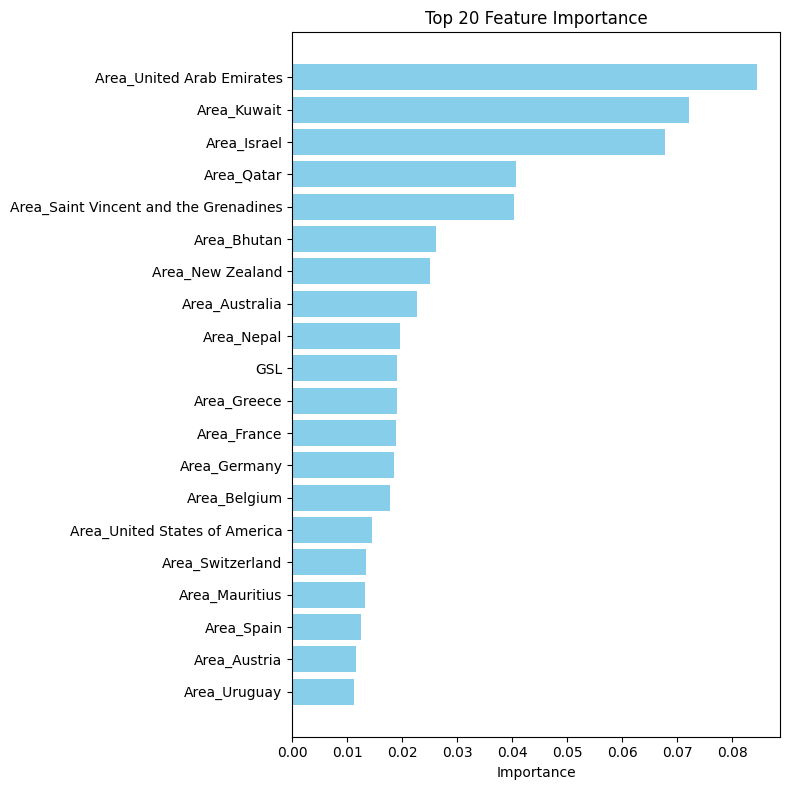

In [11]:
# 特徴量重要度 Top20 を表示・可視化（best_params で全データ学習）
import matplotlib.pyplot as plt
import pandas as pd

if 'best_params' not in locals():
    raise RuntimeError('best_params が定義されていません。上流のセルを先に実行してください。')

model = xgb.XGBRegressor(**best_params)
model.fit(X, y)

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

print('=== Feature Importance Top20 ===')
print(feat_imp.reset_index(drop=True))

plt.figure(figsize=(8, 8))
plt.barh(range(len(feat_imp)), feat_imp['importance'], color='skyblue')
plt.yticks(range(len(feat_imp)), feat_imp['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# グリッドサーチで見つかった「最良」パラメータ
best_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.2,
    'max_depth': 5,       
    'n_estimators': 300,
    'subsample': 0.9,  
    'random_state': 42,
    'n_jobs': -1
}

print("=== 時系列バックテスト（過去→未来）による過学習チェック ===")

# データを時系列で分割（例: 2005年まで学習、それ以降を予測）
# ※ regressionDF が読み込まれている前提です
train_mask = regressionDF['Year'] <= 2005
test_mask = regressionDF['Year'] > 2005

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

# モデル作成と学習
model = xgb.XGBRegressor(**best_params)
model.fit(X_train, y_train)

# 予測
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# スコア算出
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# MBE (Mean Bias Error) 計算
mbe_train = np.mean(y_pred_train - y_train)
mbe_test = np.mean(y_pred_test - y_test)

# MAPE計算（0を除外）
train_mask_nonzero = y_train != 0
test_mask_nonzero = y_test != 0
if train_mask_nonzero.sum() > 0:
    mape_train = mean_absolute_percentage_error(y_train[train_mask_nonzero], y_pred_train[train_mask_nonzero])
else:
    mape_train = np.nan
if test_mask_nonzero.sum() > 0:
    mape_test = mean_absolute_percentage_error(y_test[test_mask_nonzero], y_pred_test[test_mask_nonzero])
else:
    mape_test = np.nan

# 穀物ごとのR2計算
train_df = regressionDF.loc[train_mask].copy()
test_df = regressionDF.loc[test_mask].copy()
train_df['y_pred'] = y_pred_train
test_df['y_pred'] = y_pred_test

print("=== 穀物ごとのR2 (Train) ===")
for item in train_df['Item'].unique():
    item_mask = train_df['Item'] == item
    if item_mask.sum() > 0:
        r2_item = r2_score(train_df.loc[item_mask, 'Yield'], train_df.loc[item_mask, 'y_pred'])
        print(f"  {item}: {r2_item:.4f}")

print("\n=== 穀物ごとのR2 (Test) ===")
for item in test_df['Item'].unique():
    item_mask = test_df['Item'] == item
    if item_mask.sum() > 0:
        r2_item = r2_score(test_df.loc[item_mask, 'Yield'], test_df.loc[item_mask, 'y_pred'])
        print(f"  {item}: {r2_item:.4f}")

print("\n=== 国ごとのR2 (Train) ===")
area_r2_train = {}
for area in train_df['Area'].unique():
    area_mask = train_df['Area'] == area
    if area_mask.sum() > 0:
        r2_area = r2_score(train_df.loc[area_mask, 'Yield'], train_df.loc[area_mask, 'y_pred'])
        area_r2_train[area] = r2_area

# R2でソートして上位20位と下位40位を表示
sorted_area_r2_train = sorted(area_r2_train.items(), key=lambda x: x[1], reverse=True)
print("  上位20位:")
for area, r2_area in sorted_area_r2_train[:20]:
    print(f"    {area}: {r2_area:.4f}")
if len(sorted_area_r2_train) > 60:
    print(f"    ... 他 {len(sorted_area_r2_train)-60} 国")
print("  下位40位:")
for area, r2_area in sorted_area_r2_train[-40:]:
    print(f"    {area}: {r2_area:.4f}")
median_r2_train = np.median(list(area_r2_train.values()))
print(f"  中央値: {median_r2_train:.4f}")

print("\n=== 国ごとのR2 (Test) ===")
area_r2_test = {}
for area in test_df['Area'].unique():
    area_mask = test_df['Area'] == area
    if area_mask.sum() > 0:
        r2_area = r2_score(test_df.loc[area_mask, 'Yield'], test_df.loc[area_mask, 'y_pred'])
        area_r2_test[area] = r2_area

# R2でソートして上位20位と下位40位を表示
sorted_area_r2_test = sorted(area_r2_test.items(), key=lambda x: x[1], reverse=True)
print("  上位20位:")
for area, r2_area in sorted_area_r2_test[:20]:
    print(f"    {area}: {r2_area:.4f}")
if len(sorted_area_r2_test) > 60:
    print(f"    ... 他 {len(sorted_area_r2_test)-60} 国")
print("  下位40位:")
for area, r2_area in sorted_area_r2_test[-40:]:
    print(f"    {area}: {r2_area:.4f}")
median_r2_test = np.median(list(area_r2_test.values()))
print(f"  中央値: {median_r2_test:.4f}")
print()

print(f"訓練データ(〜2005) R2: {r2_train:.4f}")
print(f"テストデータ(2006〜) R2: {r2_test:.4f}")
print("-" * 30)
print(f"スコア差 (Train - Test): {r2_train - r2_test:.4f}")
print(f"Train RMSE: {rmse_train:.2f} / Test RMSE: {rmse_test:.2f}")
print(f"Train MBE: {mbe_train:.2f} / Test MBE: {mbe_test:.2f}")
if not np.isnan(mape_train):
    print(f"Train MAPE: {mape_train*100:.2f}% / Test MAPE: {mape_test*100:.2f}%")
else:
    print(f"Train MAPE: N/A (0値あり) / Test MAPE: {mape_test*100:.2f}%")
print(f"テストRMSE解釈: 平均で ±{rmse_test:.0f} hg/ha のズレ")
print(f"テストMBE解釈: {mbe_test:.0f} hg/ha の系統的バイアス（正=過大評価、負=過小評価）")
if not np.isnan(mape_test):
    print(f"テストMAPE解釈: 誤差率 {mape_test*100:.1f}% → 正解率目安 {100*(1-mape_test):.1f}%")
else:
    print(f"テストMAPE解釈: N/A (0値あり)")

if r2_train - r2_test > 0.2:
    print("判定:  過学習の可能性大（未来の予測には使えません）")
else:
    print("判定:  汎化性能あり（本物の精度です）")

=== 時系列バックテスト（過去→未来）による過学習チェック ===
=== 穀物ごとのR2 (Train) ===
  Maize (corn): 0.9761
  Rice: 0.9218
  Wheat: 0.9457

=== 穀物ごとのR2 (Test) ===
  Maize (corn): 0.8174
  Rice: 0.7273
  Wheat: 0.8661

=== 国ごとのR2 (Train) ===
  上位20位:
    United Arab Emirates: 0.9974
    Qatar: 0.9970
    Saint Vincent and the Grenadines: 0.9930
    Kuwait: 0.9918
    Spain: 0.9832
    Oman: 0.9790
    Greece: 0.9779
    Australia: 0.9771
    Portugal: 0.9762
    Austria: 0.9757
    Indonesia: 0.9752
    Colombia: 0.9729
    Italy: 0.9727
    Canada: 0.9727
    United States of America: 0.9720
    Israel: 0.9720
    El Salvador: 0.9681
    Ireland: 0.9678
    China: 0.9619
    Myanmar: 0.9610
    ... 他 92 国
  下位40位:
    Uzbekistan: 0.6946
    Armenia: 0.6942
    Senegal: 0.6898
    Libya: 0.6852
    Rwanda: 0.6830
    Liberia: 0.6712
    Afghanistan: 0.6696
    Tunisia: 0.6575
    Madagascar: 0.6487
    Togo: 0.6207
    Djibouti: 0.6036
    Botswana: 0.6034
    Bulgaria: 0.6002
    Ukraine: 0.5959
    Ethiopia: 0

In [11]:
# VIF (Variance Inflation Factor) を計算（多重共線性のチェック）
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

print("=== VIF (分散拡大要因) の計算 ===")

# VIFの計算関数
def calculate_vif(data):
    """VIFを計算する関数"""
    # 定数項を追加
    X = add_constant(data)
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # 定数項を除外
    vif_data = vif_data[vif_data["Variable"] != "const"]
    
    return vif_data.sort_values("VIF", ascending=False)

# 主要変数のみでVIFを計算（気候変数 + Year）
main_vars = ["Year", "SPEI", "GSL", "Hurs", "TXX"]
vif_main = calculate_vif(X[main_vars])

print("主要変数のVIF:")
print(vif_main.to_string(index=False))
print("\nVIFの解釈:")
print("- VIF < 5: 共線性の問題なし")
print("- 5 ≤ VIF < 10: 中程度の共線性")
print("- VIF ≥ 10: 高い共線性（問題あり）")

# 高いVIFを持つ変数を特定
high_vif = vif_main[vif_main["VIF"] >= 5]
if not high_vif.empty:
    print(f"\n高いVIF（≥ 5）を持つ変数:")
    print(high_vif.to_string(index=False))
else:
    print("\n高いVIF（≥ 5）を持つ変数はありません。")

=== VIF (分散拡大要因) の計算 ===
主要変数のVIF:
Variable      VIF
     TXX 3.054487
    Hurs 2.552123
     GSL 1.345665
    Year 1.027584
    SPEI 1.018549

VIFの解釈:
- VIF < 5: 共線性の問題なし
- 5 ≤ VIF < 10: 中程度の共線性
- VIF ≥ 10: 高い共線性（問題あり）

高いVIF（≥ 5）を持つ変数はありません。


In [ ]:
# 予測精度（R2スコア）上位50ヶ国を地図に表示
# 未導入の場合: %pip install plotly -q
import plotly.express as px
import numpy as np
from sklearn.metrics import r2_score

# 既に計算されているarea_r2_testがある場合はそれを使用、なければ計算
try:
    # 既存のarea_r2_test変数が存在するか確認
    if 'area_r2_test' in globals() and len(area_r2_test) > 0:
        area_r2_dict = area_r2_test
        print("既存の予測精度データを使用します")
    else:
        raise NameError("area_r2_test not found")
except (NameError, KeyError):
    # 予測精度を計算（モデルが学習されている前提）
    print("予測精度を計算中...")
    try:
        # テストデータで予測精度を計算
        test_df = regressionDF.loc[test_mask].copy()
        test_df['y_pred'] = y_pred_test
        
        area_r2_dict = {}
        for area in test_df['Area'].unique():
            area_mask = test_df['Area'] == area
            if area_mask.sum() > 0:
                r2_area = r2_score(
                    test_df.loc[area_mask, 'Yield'], 
                    test_df.loc[area_mask, 'y_pred']
                )
                area_r2_dict[area] = r2_area
        print(f"予測精度を計算しました（{len(area_r2_dict)}ヶ国）")
    except NameError as e:
        print(f"エラー: モデルが学習されていません。先にモデル学習セルを実行してください。")
        print(f"詳細: {e}")
        area_r2_dict = {}

# R2スコアでソートして全順位を取得
if len(area_r2_dict) > 0:
    area_r2_sorted = sorted(area_r2_dict.items(), key=lambda x: x[1], reverse=True)
    
    # DataFrameに変換（全順位）
    area_r2_df = pd.DataFrame(area_r2_sorted, columns=['Area', 'R2_Score'])
    area_r2_df['Rank'] = range(1, len(area_r2_df) + 1)
    
    # FAO国名 → Plotlyで認識しやすい名前に変換
    name_map = {
        'United States of America': 'United States',
        'Republic of Korea': 'South Korea',
        'Democratic People\'s Republic of Korea': 'North Korea',
        'Russian Federation': 'Russia',
        'Iran (Islamic Republic of)': 'Iran',
        'Venezuela (Bolivarian Republic of)': 'Venezuela',
        'United Republic of Tanzania': 'Tanzania',
        'Bolivia (Plurinational State of)': 'Bolivia',
        'Syrian Arab Republic': 'Syria',
        'Czechia': 'Czech Republic',
        'The former Yugoslav Republic of Macedonia': 'North Macedonia',
        'Lao People\'s Democratic Republic': 'Laos',
        'Brunei Darussalam': 'Brunei',
        'Democratic Republic of the Congo': 'Democratic Republic of the Congo',
        'Republic of Moldova': 'Moldova',
        'Viet Nam': 'Vietnam',
        'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
        'Côte d\'Ivoire': 'Ivory Coast',
    }
    area_r2_df['Country'] = area_r2_df['Area'].replace(name_map)
    
    # 地図に表示（全順位）
    fig = px.choropleth(
        area_r2_df,
        locations='Country',
        locationmode='country names',
        color='R2_Score',
        hover_name='Area',
        hover_data={'Rank': True, 'R2_Score': ':.4f', 'Country': False},
        color_continuous_scale='Viridis',
        title=f'予測精度（R2スコア）全順位（{len(area_r2_df)}ヶ国、テストデータ）'
    )
    fig.update_layout(
        margin=dict(l=0, r=0, t=40, b=0),
        height=500,
        geo=dict(showframe=False, showcoastlines=True),
    )
    fig.show()
    
    # 全順位を表示
    print(f"\n予測精度全順位（{len(area_r2_sorted)}ヶ国）:")
    print("=" * 60)
    for i, (area, r2) in enumerate(area_r2_sorted, 1):
        print(f"{i:3d}位. {area:40s} R2: {r2:7.4f}")
    print("=" * 60)
    print(f"\n平均R2スコア: {np.mean([r2 for _, r2 in area_r2_sorted]):.4f}")
    print(f"中央値R2スコア: {np.median([r2 for _, r2 in area_r2_sorted]):.4f}")
else:
    print("予測精度データがありません。")

既存の予測精度データを使用します


C:\Users\xyz19\AppData\Local\Temp\ipykernel_7928\2395571123.py:70: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.




予測精度全順位（156ヶ国）:
  1位. Dominican Republic                       R2:  0.9769
  2位. Greece                                   R2:  0.9718
  3位. Italy                                    R2:  0.9656
  4位. Republic of Korea                        R2:  0.9413
  5位. United States of America                 R2:  0.9394
  6位. Australia                                R2:  0.9343
  7位. Austria                                  R2:  0.9064
  8位. Spain                                    R2:  0.8903
  9位. Thailand                                 R2:  0.8903
 10位. El Salvador                              R2:  0.8896
 11位. Kuwait                                   R2:  0.8878
 12位. Oman                                     R2:  0.8778
 13位. Colombia                                 R2:  0.8671
 14位. Canada                                   R2:  0.8551
 15位. Peru                                     R2:  0.8540
 16位. Eswatini                                 R2:  0.8364
 17位. Costa Rica                       